# 1. Introduction

## 1.1 Project Overview

Image segmentation is one of the most classic and extensively studied tasks in computervision, with a wide range of applications—from segmenting tumors in medical images to identifying and separating different elements of a road scene in autonomous driving, such as lanes, vehicles, pedestrians, and traffic signs. Despite this, image segmentation tasks often face substantial
challenges related to data. One of the primary issues is the need for high-quality, pixel-level annotations, which are both time-consuming and expensive to produce—especially in domains like medical imaging, where expert knowledge is required. To address these challenges, unsupervised methods have been deployed to automatically generate segmentation masks required for training these data. One such method is clustering, which groups pixels based on their features—such as color, intensity, or spatial
information— into different segments. Although this might be a complex problem in cluttered images it is possible for some image datasets. In this notebook we are going to create segmentation masks for players from the [football player segmentation](https://www.kaggle.com/datasets/ihelon/football-player-segmentation) dataset.

## 1.2 Understanding Segmentation

The goal of image segmentation is to divide an image into meaningful parts or regions. This is done by assigning a label to each pixel. Note that this is different from classification where each image is assigned to one or multiple labels. This makes segmentation essential for tasks requiring
precise localization, such as identifying individual players in a football game or isolating specific objects in complex scenes. Segmentation tasks can be categorized into multiple categories.

Segmentation tasks can be categorized into multiple categories. The simplest one is **semantic segmentation**, which assigns each pixel a class label based on the object or region it belongs to, without distinguishing between different instances of the same class. For example, in a football game image, all pixels belonging to players would be labeled as "player",
regardless of which specific player they represent. **Instance Segmentation** is another type of segmentation whose goal goes beyond semantic segmentation by not only labeling pixels by their class but also differentiating between individual instances of the same class. In the football player dataset, instance segmentation would assign unique labels to each player, enabling separation of player 1 from player 2, even though both belong to the "player" class. Finally Panoptic Segmentation combines semantic and instance segmentation, labeling every pixel with both a class and, for countable objects, an instance ID. In the context of the football dataset, **panoptic segmentation** would assign unique IDs to each player while labeling background elements like the ground or crowd as single, separated regions. Focus of this project is mainly on semantic segmentation. We are going to use simple clustering approaches for this project. The reason is that it is possible to cluster image pixels where each cluster becomes one segment of the image.

# 2.1 Install Requirements2. Environment Setup

## 2.1 Install Requirements

In [ ]:
! pip install -q kaggle

## 2.2 Import Libraries

In [ ]:
import os
import json
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
from tabulate import tabulate
from pathlib import Path
from matplotlib.colors import ListedColormap
from skimage.color import rgb2gray, rgb2hsv, rgb2lab
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from scipy.ndimage import uniform_filter, median_filter
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# **3. Utils**

## 3.1 Tabulate

In [ ]:
def tabulate_dict(data: dict, headers=("Key", "Value")):
  table = [(k, v) for k, v in data.items()]
  print(tabulate(table, headers=headers, tablefmt="github"))

## 3.2 Image

In [ ]:
def extract_rgb(img):
  return img.reshape(-1, 3)

In [ ]:
def extract_height_and_width(img):
  h, w, _ = img.shape
  return h, w

In [ ]:
def visualize_segmentation(original_image, img_labels, n_clusters):
  h, w = original_image.shape[:2]
  label_map = img_labels.reshape(h, w)

  colormap = plt.colormaps['viridis'].resampled(n_clusters)
  colors = colormap(np.linspace(0, 1, n_clusters))
  cmap = ListedColormap(colors)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6),
                                 gridspec_kw={'width_ratios': [1, 1]})

  ax1.imshow(original_image)
  ax1.set_title("Original Image")
  ax1.axis('off')

  im = ax2.imshow(label_map, cmap=cmap, vmin=0, vmax=n_clusters-1)
  ax2.set_title("K-Means Segmentation")
  ax2.axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
def get_sample_image(images, features):
  sample_idx = random.randint(0, len(images) - 1)
  sample_img = images[sample_idx]
  img_features = features[sample_idx]

  return sample_img, img_features

# **4. Dataset Loading**

In [ ]:
KAGGLE_USERNAME = os.getenv('KAGGLE_USERNAME')
KAGGLE_PASSWORD = os.getenv('KAGGLE_PASSWORD')

kaggle_token = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_PASSWORD
}

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_token, f)

! chmod 600 /root/.kaggle/kaggle.json

In [ ]:
DATASET_KAGGLE_ID = "ihelon/football-player-segmentation"

In [ ]:
DATASET_PATH = "./data"
os.makedirs(DATASET_PATH, exist_ok=True)

In [ ]:
IMAGES_DIR = Path(DATASET_PATH) / "images"
ANNOTATIONS_DIR = Path(DATASET_PATH) / "annotations"

In [ ]:
! kaggle datasets download -d {DATASET_KAGGLE_ID} -p {DATASET_PATH} --unzip

Dataset URL: https://www.kaggle.com/datasets/ihelon/football-player-segmentation
License(s): CC0-1.0
 84% 268M/317M [00:00<00:00, 403MB/s]
100% 317M/317M [00:05<00:00, 64.7MB/s]


In [ ]:
IMAGES_DOWNSCALE_FACTOR = 8

all_images = list(IMAGES_DIR.glob("*.jpg"))
sampled_images = random.sample(all_images, 50)

images = []
for img_path in sampled_images:
  img = cv2.imread(str(img_path))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  h, w = img.shape[:2]
  resized = cv2.resize(img, (w // IMAGES_DOWNSCALE_FACTOR, h // IMAGES_DOWNSCALE_FACTOR))
  images.append(resized)

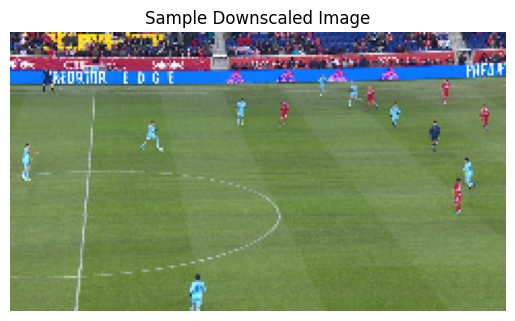

In [ ]:
plt.imshow(images[0])
plt.title("Sample Downscaled Image")
plt.axis("off")
plt.show()

In [ ]:
annotation_file = next(ANNOTATIONS_DIR.glob("*.json"))
with open(annotation_file) as f:
    annotations = json.load(f)

# **5. Features**

## 5.1 Basic Color Features

**RGB Values**: The most straightforward approach using raw pixel intensities.

- Feature vector: [R, G, B]
- Pros: Simple, fast computation
- Cons: Sensitive to lighting variations, no spatial information

**Color Space Transformations**: Converting to different color spaces can improve clustering.

- HSV: [H, S, V] - better for color-based segmentation
- LAB: [L, A, B] - perceptually uniform color space
- YUV: [Y, U, V] - Useful for lighting-invariant color segmentation.

In [ ]:
def extract_basic_color_features(img):
  rgb = extract_rgb(img)

  hsv = rgb2hsv(img).reshape(-1, 3)
  lab = rgb2lab(img).reshape(-1, 3)

  yuv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2YUV)
  yuv = yuv.astype(np.float32) / 255.0
  yuv = yuv.reshape(-1, 3)

  return rgb, hsv, lab, yuv

## 5.2 Spatial-Color Features

**Position + Color**: Combine spatial coordinates with color information.
- Feature vector: [R, G, B, X, Y] or [R, G, B, X/W, Y/H] (normalized)
- Pros: Incorporates spatial coherence
- Cons: May need to weight spatial vs. color components appropriately

**Spatial Weighting**: Scale spatial coordinates to balance with color values.
- Feature vector: [R, G, B, αX, αY] where α controls spatial influence

In [ ]:
def extract_spatial_color_features(img, spatial_weight=0.1):
  rgb = extract_rgb(img)
  h, w = extract_height_and_width(img)
  yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
  coords = np.stack((xx, yy), axis=2).reshape(-1, 2)

  coords_norm = coords.astype(np.float32)
  coords_norm[:, 0] /= w
  coords_norm[:, 1] /= h
  rgb_xy_norm = np.hstack((rgb, coords_norm))

  coords_alpha = coords.astype(np.float32) * spatial_weight
  rgb_alpha_xy = np.hstack((rgb, coords_alpha))

  return rgb_xy_norm, rgb_alpha_xy

## 5.3 Texture-Based Features

**Local Binary Patterns (LBP)** Captures local texture information.
- Calculate LBP for each pixel's neighborhood
- Feature vector: [R, G, B, LBP_value]

**Gray-Level Co-occurrence Matrix (GLCM)** Statistical texture features.
- Extract features like contrast, correlation, energy, homogeneity
- Feature vector: [R, G, B, contrast, correlation, energy, homogeneity]

In [ ]:
def extract_texture_features(img, lbp_radius=1, lbp_points=None):
  if lbp_points is None:
    lbp_points = lbp_radius * 8

  rgb = extract_rgb(img)
  h, w = extract_height_and_width(img)

  gray_img = rgb2gray(img)
  gray_uint8 = (gray_img * 255).astype(np.uint8)

  lbp = local_binary_pattern(gray_uint8, P=lbp_points, R=lbp_radius,
                             method='uniform')
  rgb_lbp = np.hstack((rgb, lbp.reshape(-1, 1)))

  glcm = graycomatrix(gray_uint8, distances=[1], angles=[0], levels=256,
                      symmetric=True, normed=True)
  contrast = graycoprops(glcm, 'contrast')[0, 0]
  correlation = graycoprops(glcm, 'correlation')[0, 0]
  energy = graycoprops(glcm, 'energy')[0, 0]
  homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
  glcm_features = np.tile([contrast, correlation, energy, homogeneity], (h * w, 1))
  rgb_glcm = np.hstack((rgb, glcm_features))

  return rgb_lbp, rgb_glcm

## 5.4 Local Neighborhood Features

**Mean and Standard Deviation in Windows**: Statistical measures of local neighborhoods.
- Calculate mean and std for color channels in NxN windows
- Feature vector: [R, G, B, R_mean, G_mean, B_mean, R_std, G_std, B_std]

**Median Filtering**: Robust to noise.
- Feature vector: [R, G, B, R_median, G_median, B_median]

In [ ]:
def extract_local_neighborhood_features(img, window_size=5):
  means = []
  stds = []
  for c in range(3):
    channel = img[:, :, c].astype(np.float32)
    local_mean = uniform_filter(channel, size=window_size, mode='reflect')
    local_mean_sq = uniform_filter(channel**2, size=window_size, mode='reflect')
    local_std = np.sqrt(local_mean_sq - local_mean**2)
    means.append(local_mean.reshape(-1, 1))
    stds.append(local_std.reshape(-1, 1))
  rgb_mean_std = np.hstack((rgb, *means, *stds))

  medians = []
  for c in range(3):
    channel = img[:, :, c].astype(np.float32)
    median = median_filter(channel, size=window_size, mode='reflect')
    medians.append(median.reshape(-1, 1))
  rgb_median = np.hstack((rgb, *medians))

  return rgb_mean_std, rgb_median

## 5.5 Extracting Features

In [ ]:
features = []

for img in images:
  image_features = {}

  rgb, hsv, lab, yuv = extract_basic_color_features(img)

  image_features["rgb"] = rgb
  image_features["hsv"] = hsv
  image_features["lab"] = lab
  image_features["yuv"] = yuv

  rgb_xy_norm, rgb_alpha_xy = extract_spatial_color_features(img)

  image_features['rgb_xy_norm'] = rgb_xy_norm
  image_features['rgb_alpha_xy'] = rgb_alpha_xy

  rgb_lbp, rgb_glcm = extract_texture_features(img)

  image_features['rgb_lbp'] = rgb_lbp
  image_features['rgb_glcm'] = rgb_glcm

  rgb_mean_std, rgb_median = extract_local_neighborhood_features(img)
  image_features['rgb_mean_std'] = rgb_mean_std
  image_features['rgb_median'] = rgb_median

  features.append(image_features)

# **6. Clustering Pixels**

## 6.1 K-Means

In [ ]:
def apply_kmeans_segmentation(img, features, feature_name, k):
  features_np = np.asarray(features)

  kmeans = KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10,
      init='k-means++',
      max_iter=300
  )

  labels = kmeans.fit_predict(features_np)
  silhouette = silhouette_score(features_np, labels)
  inertia = kmeans.inertia_

  tabulate_dict({
    'features': feature_name,
    'method': 'kmeans',
    'silhouette': float(silhouette),
    'inertia': float(inertia)
  })

  visualize_segmentation(img, labels, n_clusters=k)

  return labels

### 6.1.1 RGB Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | rgb                |
| method     | kmeans             |
| silhouette | 0.6507967194078613 |
| inertia    | 36487889.02371927  |


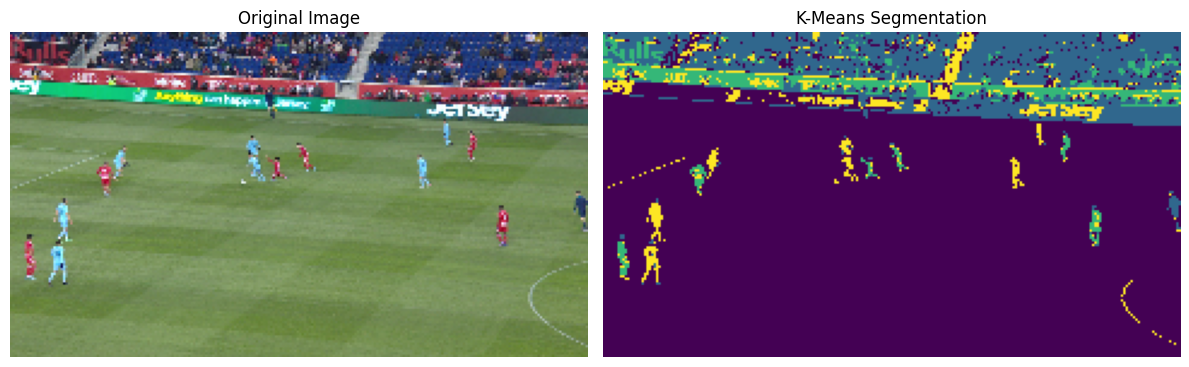

In [ ]:
labels_rgb = apply_kmeans_segmentation(img, img_features['rgb'], 'rgb', k=4)

### 6.1.2 HSV Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | hsv                |
| method     | kmeans             |
| silhouette | 0.6922724776529264 |
| inertia    | 719.7424939489806  |


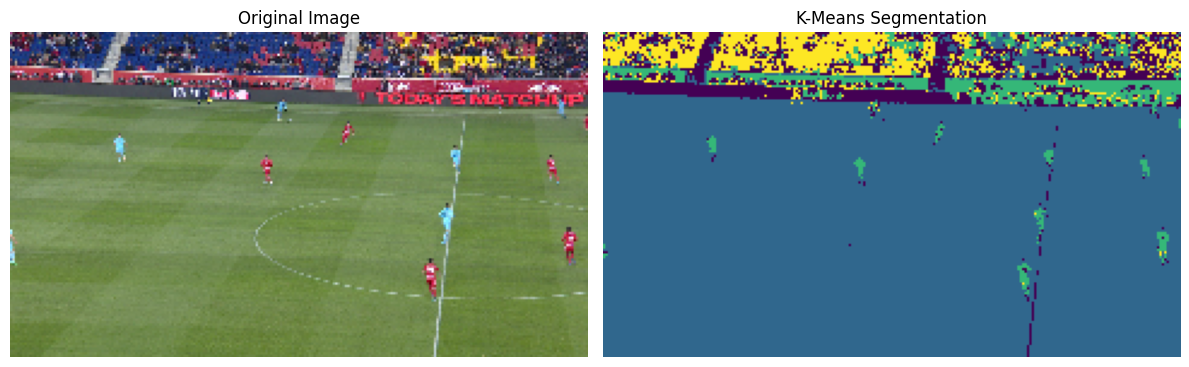

In [ ]:
labels_hsv = apply_kmeans_segmentation(img, img_features['hsv'], 'hsv', k=4)

### 6.1.3 LAB Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | lab                |
| method     | kmeans             |
| silhouette | 0.7714889404075582 |
| inertia    | 5380544.116151824  |


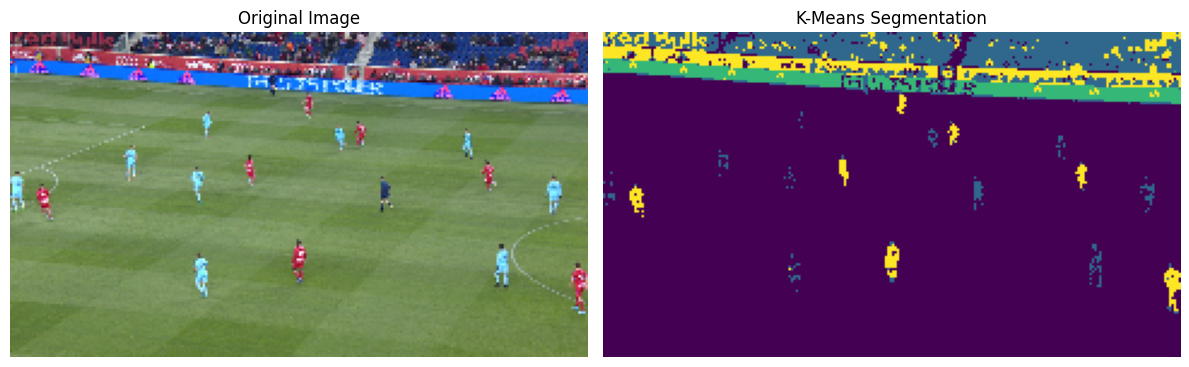

In [ ]:
labels_lab = apply_kmeans_segmentation(img, img_features['lab'], 'lab', k=4)

### 6.1.4 YUV Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | yuv                |
| method     | kmeans             |
| silhouette | 0.7096318006515503 |
| inertia    | 265.3876647949219  |


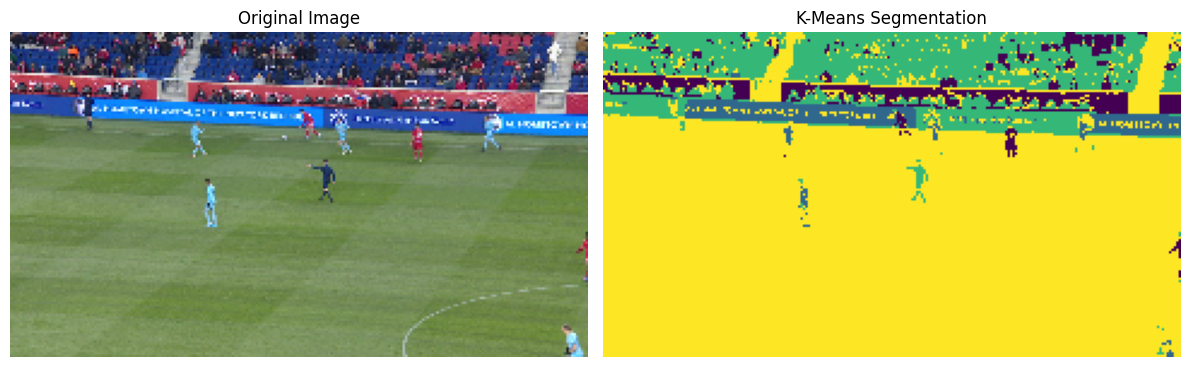

In [ ]:
labels_yuv = apply_kmeans_segmentation(img, img_features['yuv'], 'yuv', k=4)

### 6.1.5 RGB_XY_NORM Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | rgb_xy_norm        |
| method     | kmeans             |
| silhouette | 0.6770257949829102 |
| inertia    | 41600960.0         |


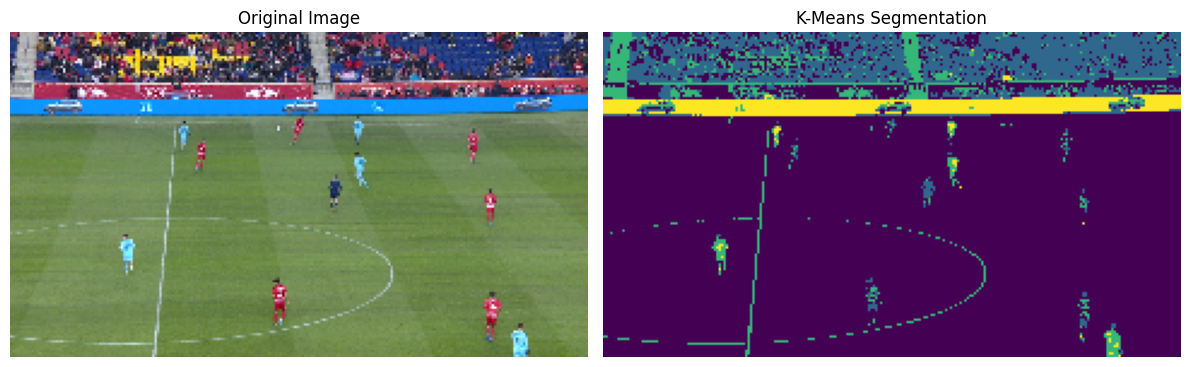

In [ ]:
labels_rgb_xy_norm = apply_kmeans_segmentation(img, img_features['rgb_xy_norm'], 'rgb_xy_norm', k=4)

### 6.1.6 RGB_ALPHA_XY Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | rgb_alpha_xy       |
| method     | kmeans             |
| silhouette | 0.6884703040122986 |
| inertia    | 38993408.0         |


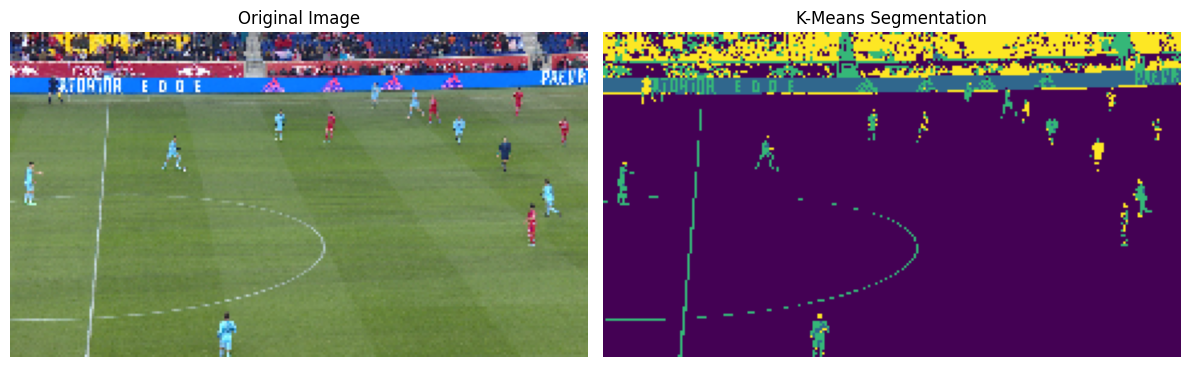

In [ ]:
labels_rgb_alpha_xy = apply_kmeans_segmentation(img, img_features['rgb_alpha_xy'], 'rgb_alpha_xy', k=4)

### 6.1.7 RGB_LBP Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | rgb_lbp            |
| method     | kmeans             |
| silhouette | 0.6866998913975936 |
| inertia    | 26897308.630110264 |


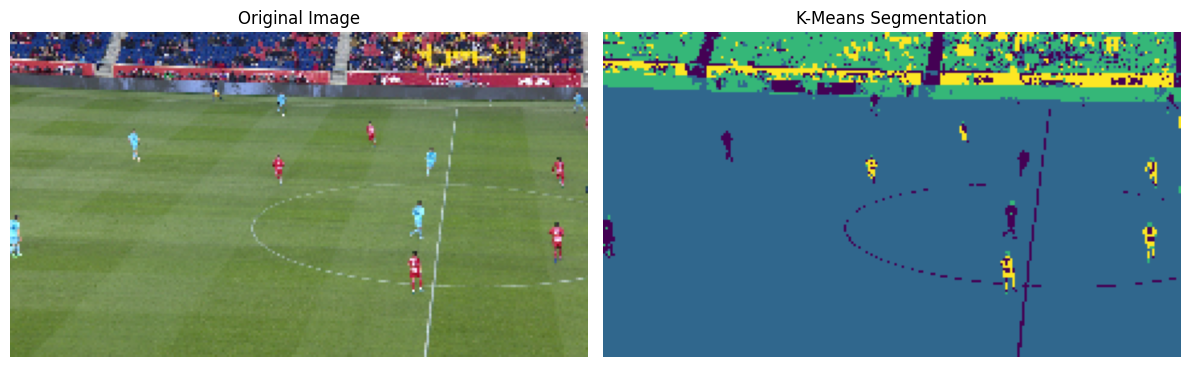

In [ ]:
labels_rgb_lbp = apply_kmeans_segmentation(img, img_features['rgb_lbp'], 'rgb_lbp', k=4)

### 6.1.8 RGB_GLCM Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | rgb_glcm           |
| method     | kmeans             |
| silhouette | 0.4610463926071602 |
| inertia    | 25913441.00116935  |


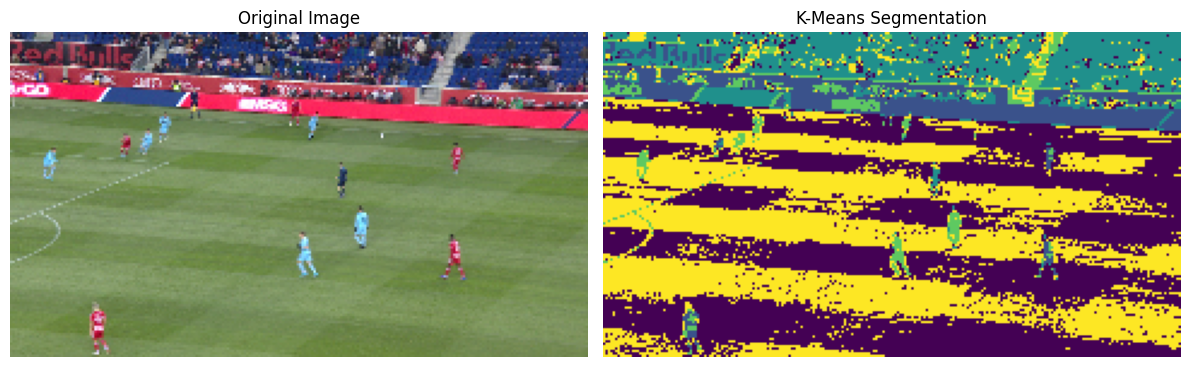

In [ ]:
labels_rgb_glcm = apply_kmeans_segmentation(img, img_features['rgb_glcm'], 'rgb_glcm', k=5)

### 6.1.9 RGB_MEAN_STD Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | rgb_mean_std       |
| method     | kmeans             |
| silhouette | 0.6168449521064758 |
| inertia    | 106743432.0        |


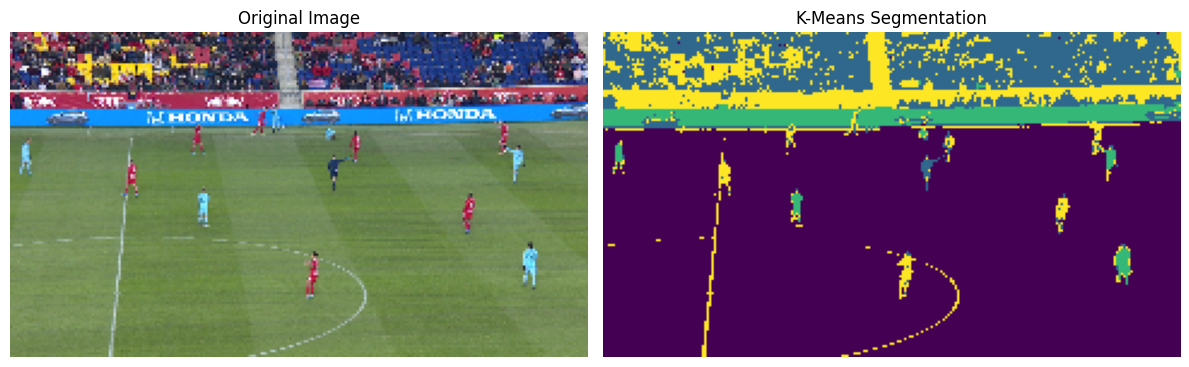

In [ ]:
labels_rgb_mean_std = apply_kmeans_segmentation(img, img_features['rgb_mean_std'], 'rgb_mean_std', k=4)

### 6.1.10 RGB_MEDIAN Features

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | rgb_median         |
| method     | kmeans             |
| silhouette | 0.4591364562511444 |
| inertia    | 34573836.0         |


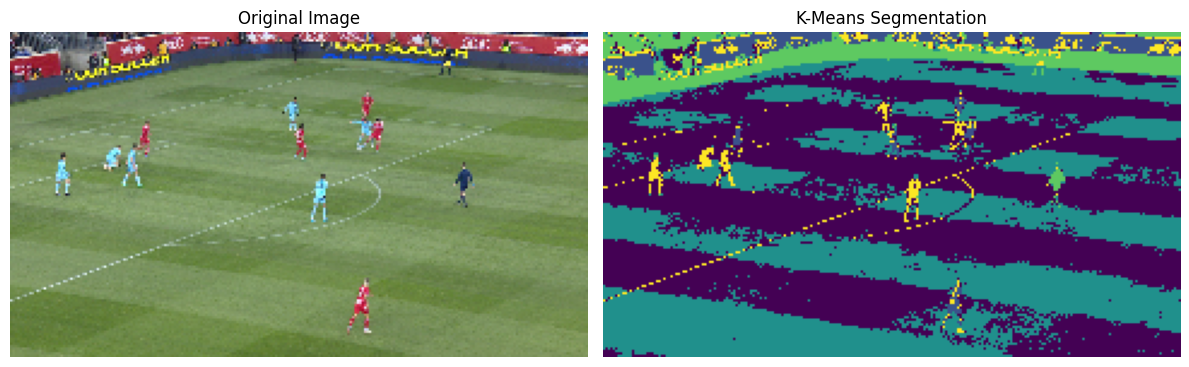

In [ ]:
labelsrgb_median = apply_kmeans_segmentation(img, img_features['rgb_median'], 'rgb_median', k=5)

# **7. Filter and Merging**

In [ ]:
UNRELATED_LABEL=-1

In [53]:
def filter_clusters_by_size(labels, min_size=10, max_size=50000):
  counts = Counter(labels)
  filtered_labels = labels.copy()

  for label, count in counts.items():
    if label == UNRELATED_LABEL:
      continue
    if count < min_size or count > max_size:
      filtered_labels[labels == label] = UNRELATED_LABEL

  return filtered_labels

In [ ]:
def merge_adjacent_clusters(labels, img):
  h, w = extract_height_and_width(img)
  label_map = labels.reshape(h, w)
  new_labels = labels.copy().reshape(h, w)
  unique_labels = [l for l in np.unique(label_map) if l != UNRELATED_LABEL]

  for label in unique_labels:
    mask = (label_map == label).astype(np.uint8)
    dilated = cv2.dilate(mask, np.ones((5, 5), np.uint8), iterations=1)

    for other_label in unique_labels:
      if other_label == label:
        continue
      other_mask = (label_map == other_label).astype(np.uint8)
      if np.any(dilated & other_mask):
        new_labels[other_mask == 1] = label

  return new_labels.reshape(-1)

In [ ]:
img, img_features = get_sample_image(images, features)

| Key        | Value              |
|------------|--------------------|
| features   | yuv                |
| method     | kmeans             |
| silhouette | 0.6900346279144287 |
| inertia    | 295.2253112792969  |


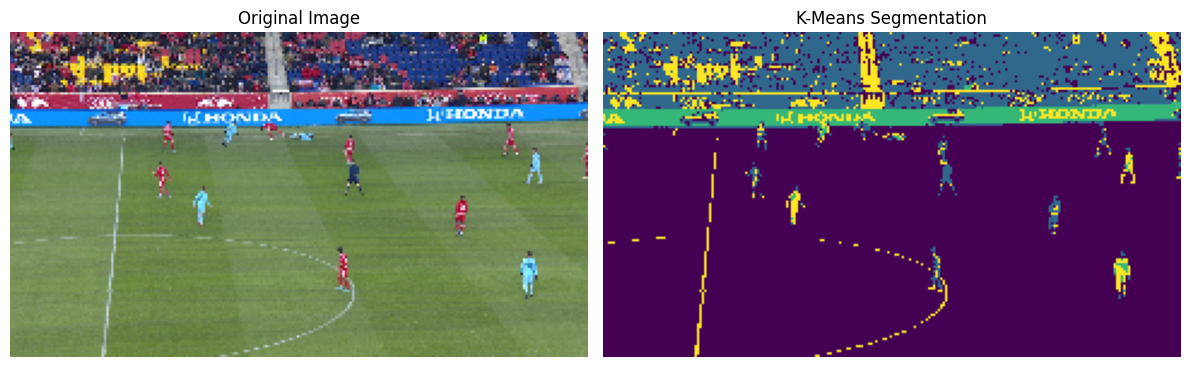

In [ ]:
labels = apply_kmeans_segmentation(img, img_features['yuv'], 'yuv', k=4)

In [54]:
filtered_labels = filter_clusters_by_size(labels)
merged_labels = merge_adjacent_clusters(
    filtered_labels,
    img
)

In [55]:
def visualize_players_only(img, merged_labels):
  remove_labels = {UNRELATED_LABEL}

  h, w = extract_height_and_width(img)
  label_map = merged_labels.reshape(h, w)

  output_img = np.zeros_like(img, dtype=np.uint8)

  unique_labels = [l for l in np.unique(label_map) if l not in remove_labels]

  colors = plt.colormaps['tab20'].resampled(len(unique_labels))

  for i, label in enumerate(unique_labels):
    mask = (label_map == label)
    color_rgb = (np.array(colors(i)[:3]) * 255).astype(np.uint8)
    output_img[mask] = color_rgb

  plt.figure(figsize=(12, 8))
  plt.imshow(output_img)
  plt.title("Players Only - Ground/Field Removed (black)")
  plt.axis('off')
  plt.show()

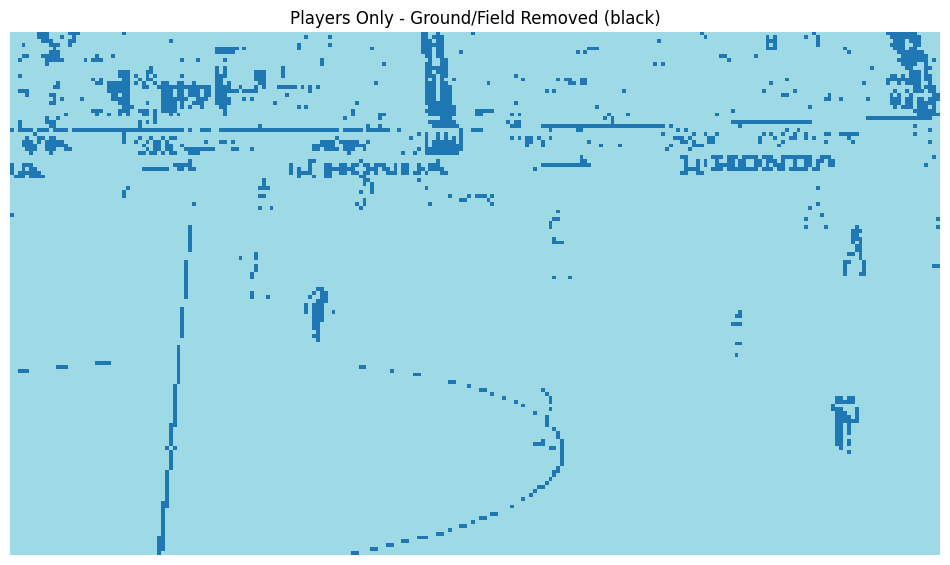

In [58]:
visualize_players_only(img, merged_labels)

# **8. Binary Maski**

# **9. Advanced Features**

# **10. Evaluation**

# **11. Questions**

1. Provide an example of a segmentation task where each type of segmentation—semantic, instance, and panoptic—is appropriate and sufficient, and explain why each type suits the specific task.


- Semantic Segmentation: Agricultural Crop Monitoring

    **Task**: Analyzing satellite imagery to determine what percentage of farmland is planted with different crop types (corn, wheat, soybeans) for agricultural planning and subsidy allocation.

    **Why semantic segmentation is sufficient**: You only need to know which pixels belong to which crop category. Individual field boundaries or distinguishing between separate corn fields isn't necessary—you just need the total area coverage of each crop type. The focus is on understanding the overall land use distribution rather than counting discrete objects.

- Instance Segmentation: Quality Control in Manufacturing

    **Task**: Inspecting circuit boards on a production line to count defective components and identify their precise locations for automated repair robots.

    **Why instance segmentation is appropriate**: You need to identify and count each individual defective component (capacitor, resistor, chip) while ignoring the background circuit board material. Each component must be treated as a separate instance even if multiple components of the same type are defective. The background (circuit board substrate, traces) isn't relevant for classification—only the individual faulty parts matter.

- Panoptic Segmentation: Autonomous Vehicle Navigation

    **Task**: Real-time scene understanding for self-driving cars to make navigation decisions in urban environments.

    **Why panoptic segmentation is necessary**: The vehicle needs comprehensive scene understanding that combines both "stuff" (road surface, sidewalk, sky, buildings) and "things" (individual cars, pedestrians, traffic signs, bicycles). For example, it must distinguish between multiple individual cars (instances) while also understanding the road surface and lane markings (semantic regions). Both types of information are critical—you can't safely navigate by only knowing object instances without understanding the drivable surface, nor can you navigate with only semantic understanding without tracking individual moving objects.

2. Explain the difference between the Dice coefficient and Intersection over Union (IoU) as evaluation metrics in image segmentation. In what scenarios might one be preferred over the other?


**Intersection over Union (IoU)**:
```
IoU = |A ∩ B| / |A ∪ B|
```
Where A is the predicted segmentation and B is the ground truth.

**Dice Coefficient**:
```
Dice = 2 × |A ∩ B| / (|A| + |B|)
```

Mathematical Relationship

These metrics are closely related. The Dice coefficient can be expressed in terms of IoU:
```
Dice = 2 × IoU / (1 + IoU)
```

This means Dice scores are always higher than IoU scores for the same segmentation quality, and Dice is more "optimistic" in its assessment.

Key Behavioral Differences

- **Sensitivity to Errors**
    - **IoU** penalizes both false positives and false negatives more severely
    - **Dice** is more forgiving, especially for smaller objects, because it weights the intersection more heavily (factor of 2 in numerator)

- **Class Imbalance Handling**
    - **Dice** tends to be more stable when dealing with small objects or rare classes
    - **IoU** can be overly harsh on small structures, potentially leading to models that ignore minority classes


**Prefer Dice Coefficient When**:

**Medical Imaging**: Segmenting small but critical structures like tumors, lesions, or blood vessels where even small improvements in detection matter more than perfect boundary precision.

**Rare Object Detection**: When your target objects occupy a very small percentage of the image (e.g., defects in manufacturing, specific cell types in microscopy).

**Training Optimization**: Dice loss often provides better gradient flow for small objects during training, helping models learn to detect minority classes.

**Prefer IoU When**:

**Autonomous Driving**: Where precise boundary detection is crucial for safety. Overestimating a pedestrian's boundary is better than underestimating it.

**Comparative Benchmarking**: IoU is more commonly used in academic benchmarks (PASCAL VOC, COCO), making it better for comparing against established baselines.

**Large Object Segmentation**: When most target objects are reasonably large relative to the image size, IoU provides a more stringent and meaningful evaluation.

**Quality Control**: Applications where false positives are costly and you want a more conservative metric.

Example:

Consider segmenting a small tumor (100 pixels) where your model:
- Correctly identifies 80 pixels
- Misses 20 pixels (false negatives)  
- Incorrectly includes 30 pixels (false positives)

```
IoU = 80 / (100 + 30) = 0.615
Dice = 2 × 80 / (100 + 110) = 0.762
```

The Dice score suggests "good" performance while IoU indicates "moderate" performance. In medical contexts, the Dice score might be more encouraging for detecting small critical structures, while in precision-critical applications, the IoU's stricter assessment might be more appropriate.


Many practitioners use both metrics together: Dice for training (as a loss function) due to its better optimization properties for imbalanced data, and IoU for evaluation and comparison due to its widespread adoption and stricter assessment of segmentation quality.

3. Imagine a scenario where we need to cluster a large set of images into multiple categories. Methods such as K-means can become computationally expensive and inefficient when applied directly to high-dimensional image data. One approach to address this issue is to use an autoencoder architecture to reduce the dimensionality of the images before clustering. Explain how autoencoders can be used for this purpose. How does this method help improve the efficiency and effectiveness of clustering algorithms like K-means on large image datasets?

Autoencoders provide an elegant solution to the curse of dimensionality problem in image clustering by learning compressed representations that preserve the most important features while dramatically reducing computational complexity.

**How Autoencoders Enable Efficient Image Clustering**

- **Dimensionality Reduction Through Representation Learning**
An autoencoder learns to compress high-dimensional images (e.g., 256×256×3 = 196,608 dimensions) into a much smaller latent space (e.g., 128 or 512 dimensions) while preserving the essential visual features. The encoder network maps images to this compact representation, while the decoder attempts to reconstruct the original image, forcing the bottleneck layer to capture the most informative aspects of the data.

  **The Two-Stage Process**
  1. **Pre-training Phase**: Train the autoencoder on your image dataset to learn meaningful low-dimensional representations
  2. **Clustering Phase**: Extract the latent representations (encoder outputs) and apply K-means or other clustering algorithms to these compressed features

**Efficiency Improvements**

- **Computational Complexity Reduction**
K-means complexity scales with both the number of data points and dimensionality. For n images with d dimensions and k clusters over t iterations, the complexity is O(n×d×k×t). Reducing dimensionality from ~200,000 to ~500 dimensions represents a 400× reduction in this computational burden.

- **Memory Usage**
Storing and processing compressed representations requires significantly less RAM, enabling clustering of larger datasets that might not fit in memory when using raw pixel values.

- **Convergence Speed**
Lower-dimensional spaces typically lead to faster K-means convergence, as the algorithm needs fewer iterations to find stable cluster centroids.

**Effectiveness Improvements**

- **Feature Relevance**
Raw pixel intensities often contain noise and irrelevant details that can mislead clustering algorithms. Autoencoders learn to extract semantically meaningful features that better represent the underlying structure of the data. For example, instead of clustering based on slight color variations, the algorithm focuses on shapes, textures, and objects.

- **Distance Metric Meaningfulness**
In high-dimensional pixel space, Euclidean distance (used by K-means) becomes less discriminative due to the curse of dimensionality. In the learned latent space, distances between points become more meaningful for clustering purposes.

- **Handling Non-Linear Relationships**
Linear dimensionality reduction techniques like PCA might miss important non-linear patterns in image data. Autoencoders can capture complex non-linear relationships between visual features, leading to better clustering results.